<a href="https://colab.research.google.com/github/shylayadav1/CNIT484-SP500-Project/blob/main/CNIT484_S%26P_500.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Load and read S&P 500 dataset

In [ ]:
from google.colab import drive
import pandas as pd
import os

In [ ]:
drive.mount ('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/MyDrive/CNIT 484 Project/archive/sp500_v1_master.csv'

df = pd.read_csv(file_path)

Data Cleaning

In [ ]:
df.columns = [col.lower().strip().replace(' ', '_') for col in df.columns]

In [ ]:
print('DataFrame columns:', df.columns.tolist())

DataFrame columns: ['open', 'high', 'low', 'close', 'volume', 'dividends', 'stock_splits', 'adj_close']


In [ ]:
df = df[df['high'] >= df['low']] #data integrity check

In [ ]:
#checking for no negative prices or volumes
df = df[(df[['open', 'high', 'low', 'close', 'adj_close']] > 0).all(axis=1)]
df = df[df['volume'] >= 0]
df = df[df['high'] >= df['low']]

In [ ]:
#standardize metrics
df['daily_return'] = df['adj_close'].pct_change() #daily return
df['daily_range_pct'] = (df['high'] - df['low']) / df['open']  #daily volatility

In [ ]:
print(df[['dividends', 'stock_splits']].sum())
print("Dividends reported:", df['dividends'].gt(0).sum())
print("Stock splits reported:", df['stock_splits'].gt(0).sum())

dividends       12611.806748
stock_splits     2627.841548
dtype: float64
Dividends reported: 43723
Stock splits reported: 1365


Visualizations

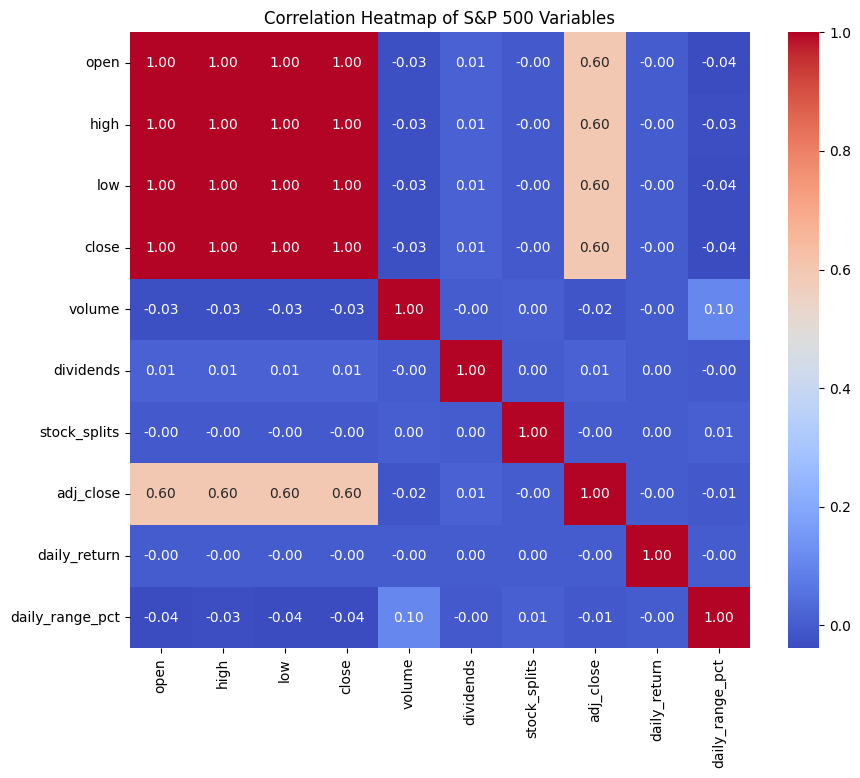

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt
#heatmaps for team to get a better understanding about possible correlations to
#investigate
plt.figure(figsize=(10, 8))
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap of S&P 500 Variables')
plt.show()

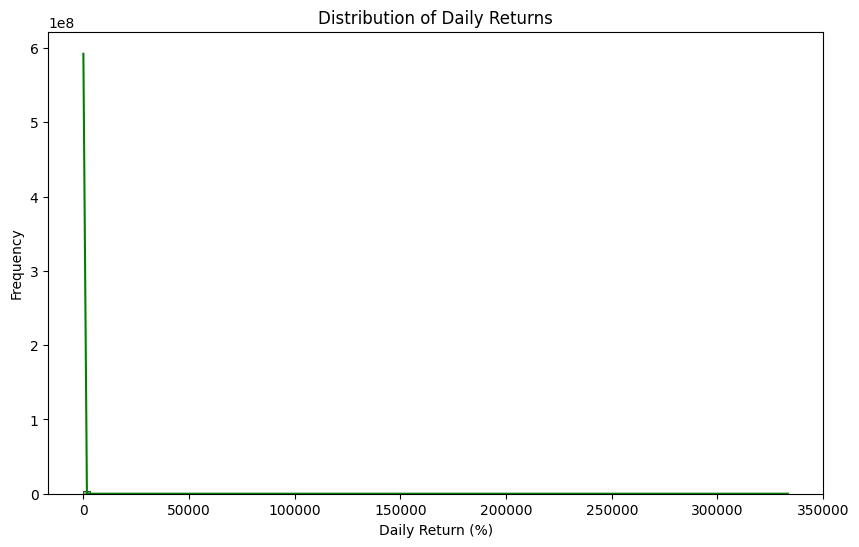

In [ ]:
plt.figure(figsize=(10, 6))
#histogram
sns.histplot(df['daily_return'].dropna(), bins=100, kde=True, color='green')
plt.title('Distribution of Daily Returns')
plt.xlabel('Daily Return (%)')
plt.ylabel('Frequency')
plt.show()

In [45]:
!git clone --branch master https://github.com/shylayadav1/CNIT484-SP500-Project.git

Cloning into 'CNIT484-SP500-Project'...
fatal: Remote branch master not found in upstream origin


In [50]:
!git ls-remote --heads https://github.com/shylayadav1/CNIT484-SP500-Project.git

5bc3753ef44a3535ea91a11009843794a9281e03	refs/heads/main
